## Problem Statement: Handwritten Alphabet Recognition. 
### Objective:
#### Design, train, and deploy a robust Deep Learning classifier that accepts an image of a single handwritten English alphabet and accurately predicts its character class ($A$ through $Z$, 26 classes) with a target test accuracy of 98%, while maintaining a strict inference latency budget.

In [1]:
# Numerical Computing
import numpy as np

# Data Manipulation
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Image Processing
import cv2
import os

from tqdm import tqdm
from sklearn.pipeline import Pipeline

# Machine Learning
from sklearn.model_selection import train_test_split



# Feature Extraction
from skimage.feature import hog

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


import joblib


import mediapipe as mp

import warnings
warnings.filterwarnings("ignore")

In [2]:
dataset_path = r"C:\Users\LENOVO\Downloads\archive (21)" 
import os
if os.path.exists(dataset_path):
    classes = sorted(os.listdir(dataset_path))
    print("Success! Classes found:", classes)
else:
    print("Error: Python still cannot find this path. Double-check the folder name.")

Success! Classes found: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'english_alphabets']


In [3]:
# Count 
import os

total_images = 0

for cls in classes:
    folder = os.path.join(dataset_path, cls)
    total_images += len(os.listdir(folder))

print("Total Images:", total_images)

Total Images: 6857


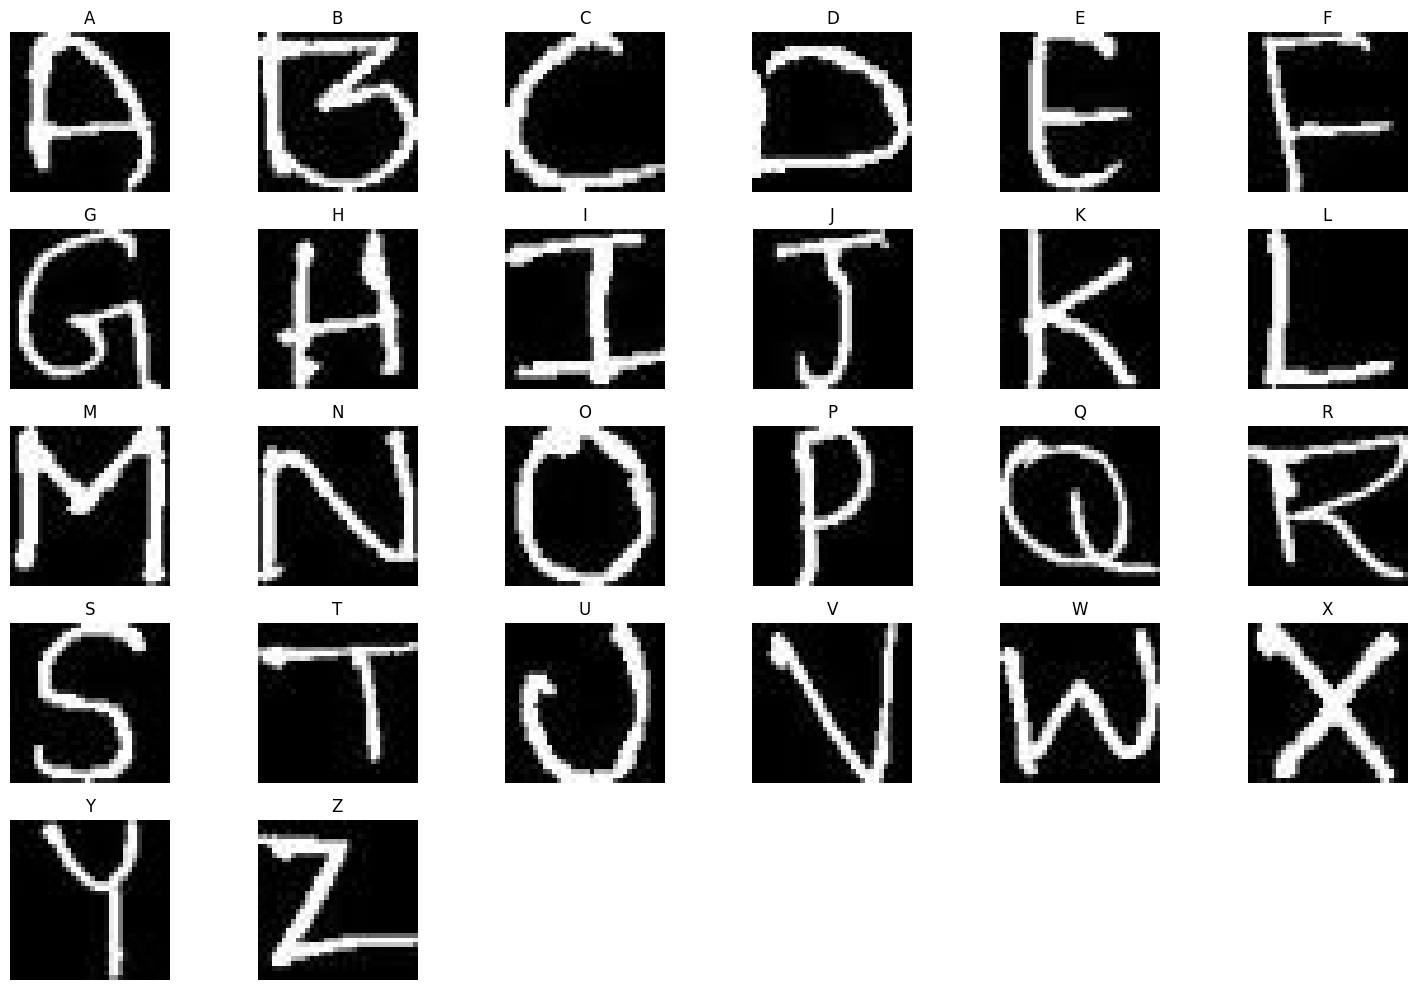

In [4]:
# Sample Images
import os
import cv2
import matplotlib.pyplot as plt

# 1. Define your dataset path (Ensure this points to your actual folder)
dataset_path = r"C:\Users\LENOVO\Downloads\archive (21)"  

# 2. Define or extract the classes (Sorted to keep A-Z order)
classes = sorted(os.listdir(dataset_path)) 

# 3. Plot the sample images
plt.figure(figsize=(15, 10))

for i, cls in enumerate(classes):
    # Get the first image file name in the class folder
    img_names = os.listdir(os.path.join(dataset_path, cls))
    if not img_names:
        continue # Skip empty folders to prevent IndexError
        
    img_name = img_names[0]
    img_path = os.path.join(dataset_path, cls, img_name)

    image = cv2.imread(img_path)
    if image is None:
        print(f"Warning: Could not read image at {img_path}")
        continue
        
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(5, 6, i + 1)
    plt.imshow(image)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
# Image Dimensions
sample_class = classes[0]
sample_folder = os.path.join(dataset_path, sample_class)

sample_image = os.listdir(sample_folder)[0]
sample_path = os.path.join(sample_folder, sample_image)

img = cv2.imread(sample_path)

print("Image Shape :", img.shape)
print("Height :", img.shape[0])
print("Width :", img.shape[1])
print("Channels :", img.shape[2])

Image Shape : (34, 34, 3)
Height : 34
Width : 34
Channels : 3


### Observations:
- in the dataset no.of images: 6831.
- in the dataset no.of classes: 26.
- Image size is 34 × 34 × 3.
- Images are in all alphabet classes.


In [6]:
# Exploration Data Anyalasis (EDA)
# Images in each Class
class_counts = {}

for cls in classes:
    folder = os.path.join(dataset_path, cls)
    class_counts[cls] = len(os.listdir(folder))

print(class_counts)

{'A': 391, 'B': 272, 'C': 297, 'D': 274, 'E': 249, 'F': 284, 'G': 250, 'H': 229, 'I': 201, 'J': 227, 'K': 217, 'L': 282, 'M': 261, 'N': 350, 'O': 292, 'P': 336, 'Q': 251, 'R': 239, 'S': 263, 'T': 226, 'U': 237, 'V': 244, 'W': 237, 'X': 272, 'Y': 210, 'Z': 240, 'english_alphabets': 26}


In [7]:
# Distribution of classes
import pandas as pd

df = pd.DataFrame({
    "Class": class_counts.keys(),
    "Images": class_counts.values()})

df

,Class,Images
0,A,391
1,B,272
2,C,297
3,D,274
4,E,249
5,F,284
6,G,250
7,H,229
8,I,201
9,J,227


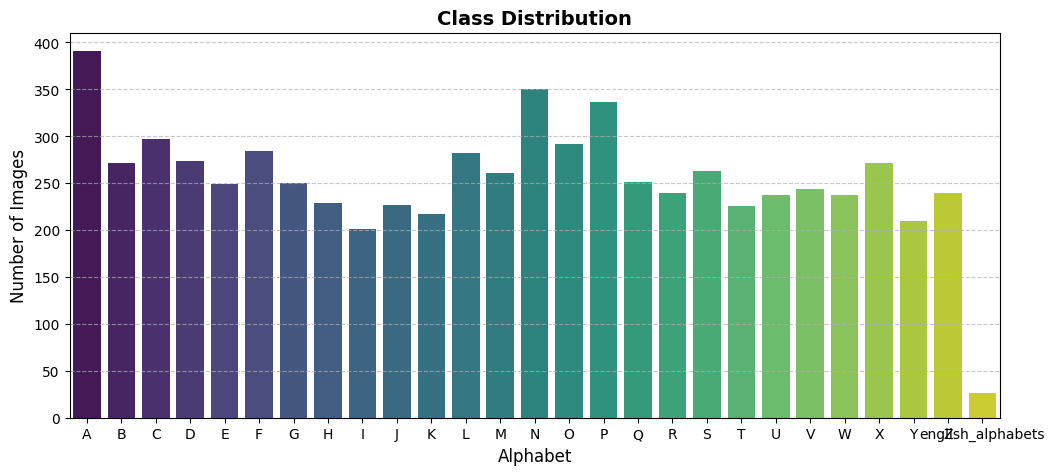

In [8]:
# count Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Seaborn automatically colors bars and applies a clean grid
sns.barplot(data=df, x="Class", y="Images", palette="viridis")

plt.title("Class Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Alphabet", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)  # Adds a clean background grid

plt.show()

In [9]:
# Distribution Percentages
df["Percentage"] = (df["Images"] / total_images) * 100
df

,Class,Images,Percentage
0,A,391,5.702202
1,B,272,3.966749
2,C,297,4.331340
3,D,274,3.995917
4,E,249,3.631326
5,F,284,4.141753
6,G,250,3.645909
7,H,229,3.339653
8,I,201,2.931311
9,J,227,3.310486


In [10]:
import os
import cv2
import pandas as pd

dimensions = []

for cls in classes:
    folder = os.path.join(dataset_path, cls)
    for img_name in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, img_name))
        if img is not None:
            dimensions.append({"Height": img.shape[0], "Width": img.shape[1]})

# Convert to DataFrame
df_dims = pd.DataFrame(dimensions)

# Instantly prints min, max, mean, and quartiles for both columns
print(df_dims.describe().loc[['min', 'max']])

     Height  Width
min    34.0   34.0
max    34.0   34.0


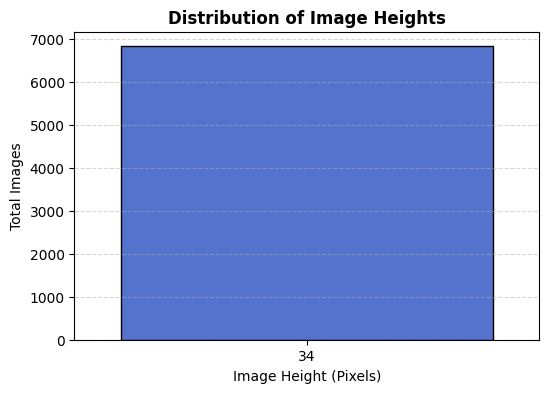

In [11]:
# Image Resolution Distribution
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

# FIX: Pull the column directly from your df_dims DataFrame
sns.countplot(data=df_dims, x="Height", color="royalblue", edgecolor="black")

plt.title("Distribution of Image Heights", fontsize=12, fontweight="bold")
plt.xlabel("Image Height (Pixels)")
plt.ylabel("Total Images")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

> Observations:
- Dataset Volume: 6,831 images across all 26 classes (A–Z).
- Dimensions: 100% of the images have a uniform, square resolution of exactly 34 * 34 pixels.
> Insights
- Zero Resizing Needed: The perfectly uniform image size means you can completely skip uniform cropping or image  interpolation scripts.
- Feature Extraction: Flattening the raw pixels yields a feature matrix shape of (6831, 3468).


## Image Preprocessing

In [12]:
images = []
labels = []

image_size = (34, 34)

for cls in classes:
    folder = os.path.join(dataset_path, cls)

    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)

        img = cv2.imread(img_path)

        # Skip corrupted images
        if img is None:
            continue

        # Resize image
        img = cv2.resize(img, image_size)

        # Convert BGR to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Normalize pixel values
        img = img.astype(np.float32) / 255.0

        images.append(img)
        labels.append(cls)

images = np.array(images)
labels = np.array(labels)

print("Images Shape :", images.shape)
print("Labels Shape :", labels.shape)

Images Shape : (6831, 34, 34, 3)
Labels Shape : (6831,)


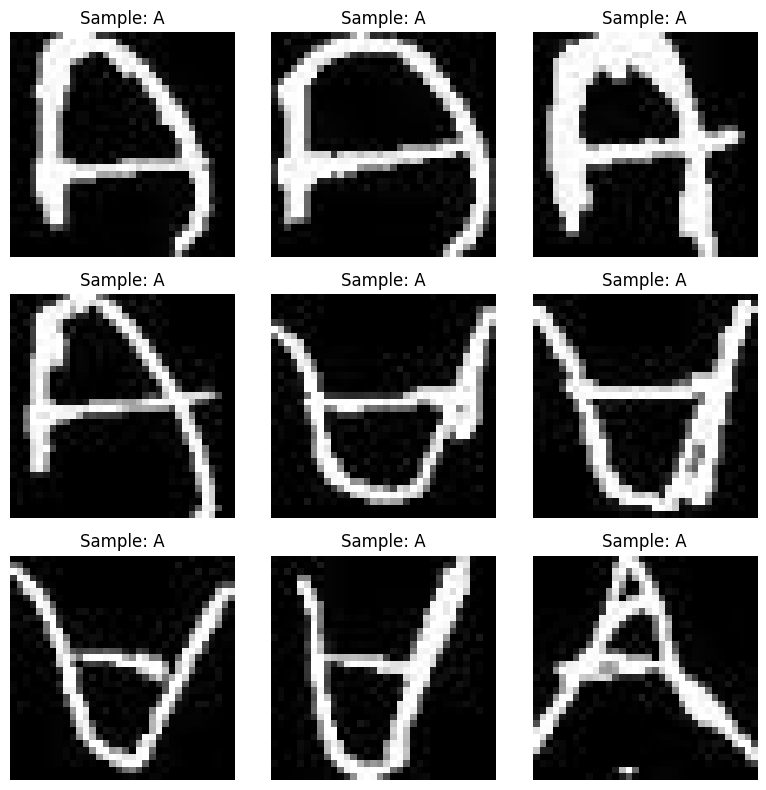

In [13]:
plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(f"Sample: {labels[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [14]:
# Verify Pixel Values
print("Minimum Pixel Value :", images.min())
print("Maximum Pixel Value :", images.max())

Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0


# Feature Extraction - Flattening Pixels

In [15]:
# Calculate total pixels per image explicitly (34 * 34 * 3 = 3468)
num_features = images.shape[1] * images.shape[2] * images.shape[3]

# Flatten while keeping the batch size intact
X = images.reshape(images.shape[0], num_features)

print("Feature Matrix Shape :", X.shape)

Feature Matrix Shape : (6831, 3468)


> Observations:
- All 6,831 images were successfully flattened into 1D vectors of 3,468 features (34 * 34 * 3 channels).
> Insight:
- This formats raw spatial data into a uniform structure required by classical algorithms (Random Forest, SVM, KNN) and avoids shape mismatches during training.

# Label Encoding

In [16]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(labels)

print("Target Shape :", y.shape)
print("Encoded Classes :", label_encoder.classes_)

Target Shape : (6831,)
Encoded Classes : ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']


In [17]:
print("X Shape :", X.shape)
print("y Shape :", y.shape)

X Shape : (6831, 3468)
y Shape : (6831,)


# Train_Test_Split

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5464, 3468)
(1367, 3468)
(5464,)
(1367,)


# Model Building

In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC


# K-nn

knn_model = KNeighborsClassifier(
    n_neighbors=3,
    weights="distance",
    metric="euclidean")

print("Training KNN started")
knn_model.fit(X_train, y_train)
print("KNN Training Completed")


#  Naive Bayes

nb_model = GaussianNB()
print("\nTraining Naive Bayes started")
nb_model.fit(X_train, y_train)
print("Naive Bayes Training Completed")



# Desision Tree

dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=1,
    random_state=42)

print("\nTraining Decision Tree started")
dt_model.fit(X_train, y_train)
print("Decision Tree Training Completed")



# Logestic Regression


lr_model = LogisticRegression(
    max_iter=5000,
    random_state=42)

print("\nTraining Logistic Regression started")
lr_model.fit(X_train, y_train)
print("Logistic Regression Training Completed")



# Linear SVM


svm_model = LinearSVC(
    C=1.0,
    max_iter=10000,
    random_state=42
)

print("\nTraining Linear SVM started")
svm_model.fit(X_train, y_train)

print("Linear SVM Training Completed")



Training KNN...
KNN Training Completed!

Training Naive Bayes...
Naive Bayes Training Completed!

Training Decision Tree...
Decision Tree Training Completed!

Training Logistic Regression...
Logistic Regression Training Completed!

Training Linear SVM...
Linear SVM Training Completed!


# Model Evaluation

In [20]:

# MODEL EVALUATION 


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

import pandas as pd



# Prediction


y_pred_knn = knn_model.predict(X_test)
y_pred_nb = nb_model.predict(X_test)
y_pred_dt = dt_model.predict(X_test)
y_pred_lr = lr_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test)



# Models and prediction storing

predictions = {
    "K-Nearest Neighbors": y_pred_knn,
    "Naive Bayes": y_pred_nb,
    "Decision Tree": y_pred_dt,
    "Logistic Regression": y_pred_lr,
    "Linear SVM": y_pred_svm
}



# Evaluate


results = []

for model_name, y_pred in predictions.items():

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0)

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0)

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1})


# Comparision Table

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="Accuracy",ascending=False).reset_index(drop=True)

print("\nModel Comparision")


print(results_df.to_string(index=False))



# Best Model

best_model = results_df.iloc[0]

print("BEST MODEL")

print("Model     :", best_model["Model"])
print("Accuracy  :", round(best_model["Accuracy"], 3))
print("Precision :", round(best_model["Precision"], 3))
print("Recall    :", round(best_model["Recall"], 3))
print("F1 Score  :", round(best_model["F1 Score"], 3))




Model Comparision
              Model  Accuracy  Precision   Recall  F1 Score
K-Nearest Neighbors  0.836869   0.849908 0.836869  0.835727
Logistic Regression  0.818581   0.821119 0.818581  0.818406
         Linear SVM  0.755669   0.758713 0.755669  0.754991
        Naive Bayes  0.694952   0.722699 0.694952  0.690210
      Decision Tree  0.505486   0.510784 0.505486  0.504856

BEST MODEL
Model     : K-Nearest Neighbors
Accuracy  : 0.8369
Precision : 0.8499
Recall    : 0.8369
F1 Score  : 0.8357


# Hyperparameter tuning

In [21]:

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report)



# Pipeline
rf_pipeline = Pipeline([( "classifier",RandomForestClassifier(random_state=42,n_jobs=-1))])



# Hyperperameter 

param_dist = {

    "classifier__n_estimators": [200,300,500],

    "classifier__max_depth": [None,20,30,40],

    "classifier__min_samples_split": [2,5,10],

    "classifier__min_samples_leaf": [1,2,4],

    "classifier__max_features": ["sqrt","log2"],

    "classifier__class_weight": [None,"balanced"]}



# Randamized search

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist,
    n_iter=15,
    scoring="accuracy",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1)


print("Random Forest Hyperparameter Tuning")
rf_search.fit(
    X_train,
    y_train)
print("\nRandom Forest Hyperparameter Tuning Completed")



# Best Parameter

print("\nBest Parameters:")
print(rf_search.best_params_)



# Best cross validation 

print("\nBest Cross Validation Score:")

print(rf_search.best_score_)



# Final pipeline tuning
best_rf_pipeline = rf_search.best_estimator_


# Test Predicition
y_pred_best_rf = best_rf_pipeline.predict(X_test)



# Evalution metrics

rf_accuracy = accuracy_score(
    y_test,
    y_pred_best_rf)

rf_precision = precision_score(
    y_test,
    y_pred_best_rf,
    average="weighted",
    zero_division=0)

rf_recall = recall_score(
    y_test,
    y_pred_best_rf,
    average="weighted",
    zero_division=0)

rf_f1 = f1_score(y_test,
                 y_pred_best_rf,
                 average="weighted",
                 zero_division=0)



# Results
print("Results of RandomForest tuned")
print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")



# Classification Report
print("\nClassification Report")
print(classification_report(y_test,y_pred_best_rf,zero_division=0))

Starting Random Forest Hyperparameter Tuning...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Random Forest Hyperparameter Tuning Completed!

Best Parameters:
{'classifier__n_estimators': 300, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'log2', 'classifier__max_depth': 40, 'classifier__class_weight': None}

Best Cross Validation Score:
0.8404079695498687

TUNED RANDOM FOREST RESULTS
Accuracy  : 0.8559
Precision : 0.8591
Recall    : 0.8559
F1 Score  : 0.8554

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.92      0.91        78
           1       0.78      0.87      0.82        54
           2       0.87      0.97      0.91        60
           3       0.83      0.82      0.83        55
           4       0.91      0.78      0.84        50
           5       0.94      0.81      0.87        57
           6       0.88      0.74      0.80        50
           


Random Forest Hyperparameter Tuning Completed!

Best Parameters:
{'classifier__n_estimators': 300, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'log2', 'classifier__max_depth': 40, 'classifier__class_weight': None}

Best Cross Validation Score:
0.8404079695498687

TUNED RANDOM FOREST RESULTS
Accuracy  : 0.8559
Precision : 0.8591
Recall    : 0.8559
F1 Score  : 0.8554

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.92      0.91        78
           1       0.78      0.87      0.82        54
           2       0.87      0.97      0.91        60
           3       0.83      0.82      0.83        55
           4       0.91      0.78      0.84        50
           5       0.94      0.81      0.87        57
           6       0.88      0.74      0.80        50
           7       0.93      0.87      0.90        46
           8       0.67      0.78      0.72        40
           9

# Confusion Matrix

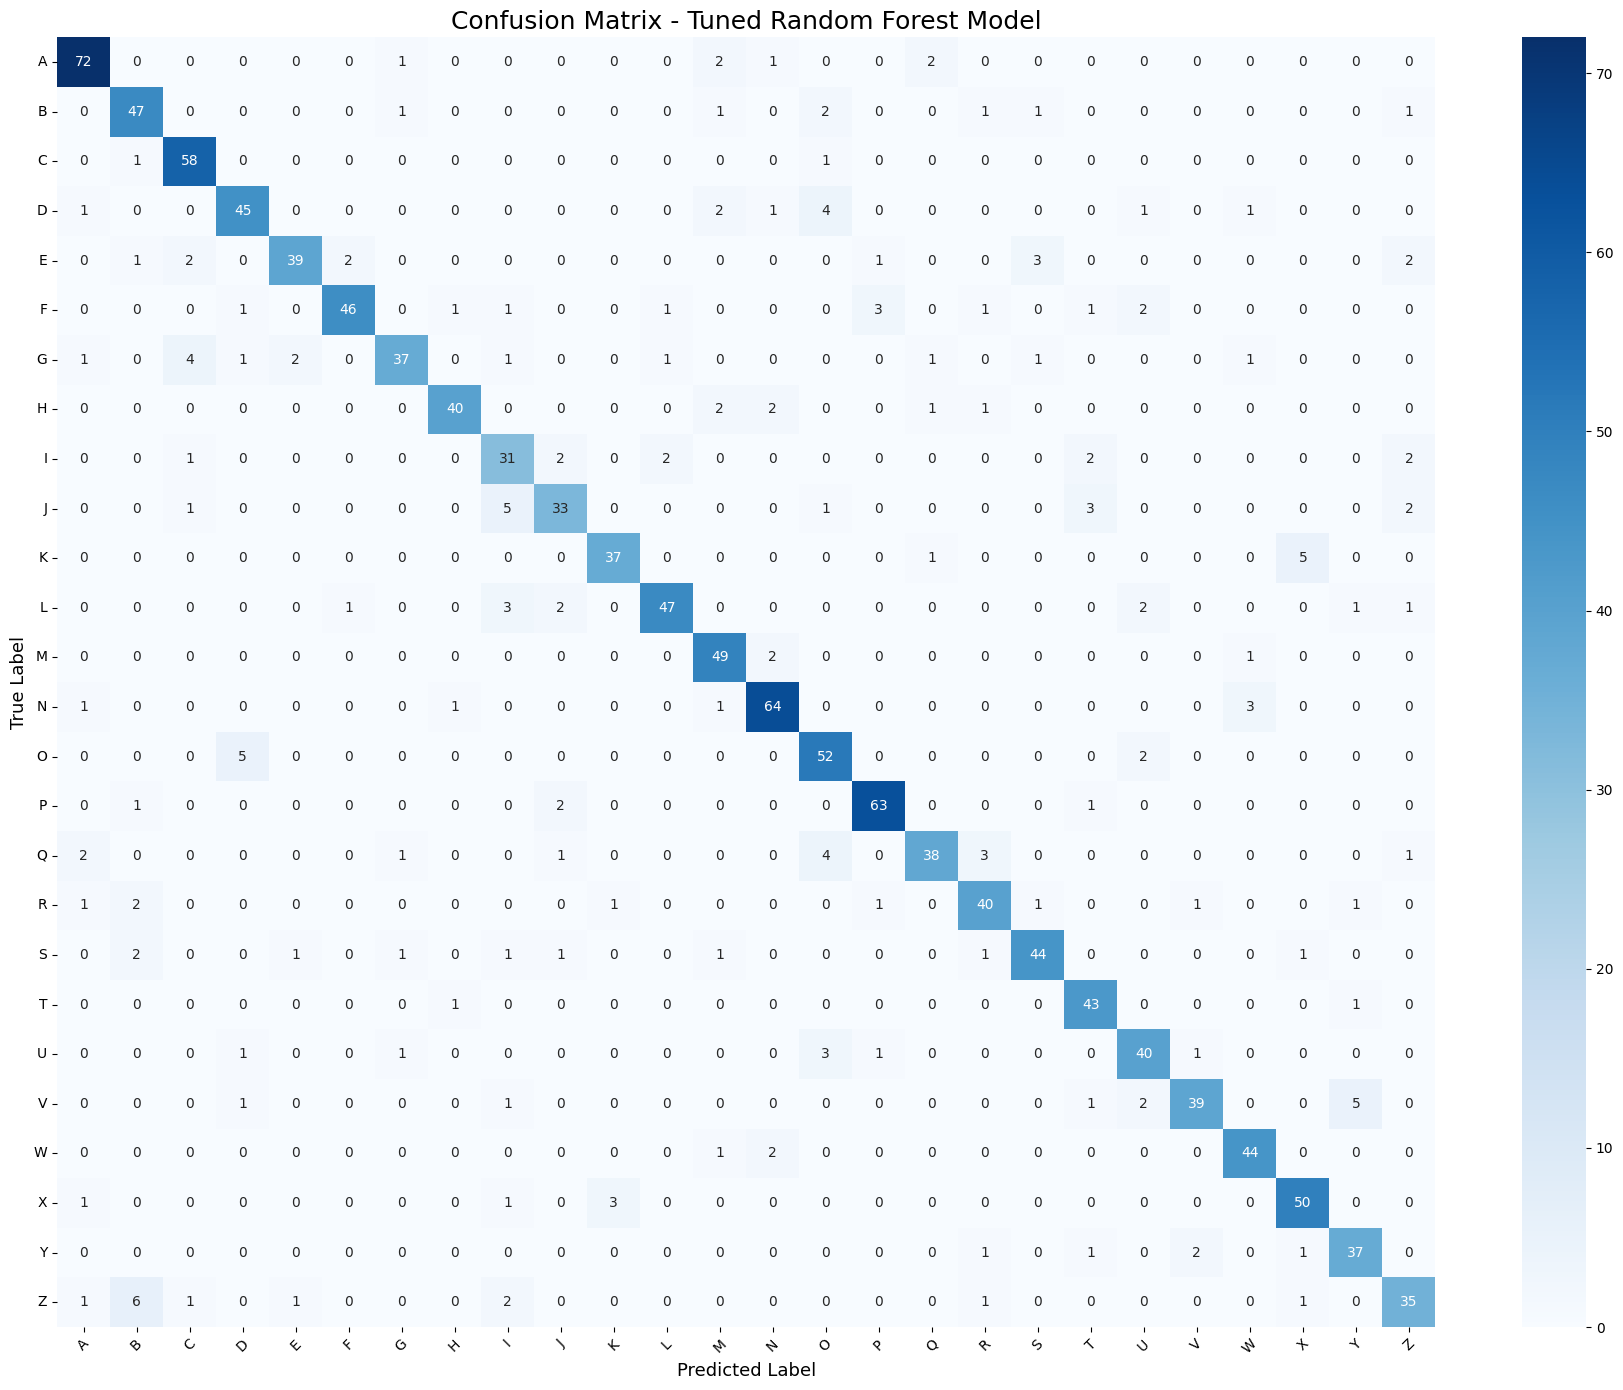

In [29]:
# ============================================================
# CONFUSION MATRIX - TUNED RANDOM FOREST
# ============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import string


# confusion Matrix
cm_rf = confusion_matrix(y_test,y_pred_best_rf)


class_labels = list(string.ascii_uppercase) # class labels A-Z


# Confusion Matrix
plt.figure(figsize=(18, 14))
sns.heatmap(cm_rf, annot=True,fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix - Tuned Random Forest Model",fontsize=18)
plt.xlabel("Predicted Label",fontsize=13)
plt.ylabel("True Label",fontsize=13)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Model Saving

In [26]:
import joblib

# FINAL MODEL
final_model = best_rf_pipeline
joblib.dump(final_model, "alphabet_rf_pipeline.pkl")

print("Final tuned Random Forest")
print("alphabet_rf_pipeline.pkl")

Final tuned Random Forest
alphabet_rf_pipeline.pkl


In [28]:


import joblib
from sklearn.metrics import accuracy_score

# LOAD SAVED PIPELINE

loaded_rf_pipeline = joblib.load(
    "alphabet_rf_pipeline.pkl")
print("pipeline loaded")
# PREDICT TEST DATA


loaded_predictions = loaded_rf_pipeline.predict(
    X_test
)



#  Accuracy check

loaded_accuracy = accuracy_score(y_test,loaded_predictions)



# DISPLAY RESULT

print(f"Loaded Model Accuracy: {loaded_accuracy:.4f}")

print(f"Expected Accuracy    : {rf_accuracy:.4f}")

pipeline loaded
Loaded Model Accuracy: 0.8559
Expected Accuracy    : 0.8559
